In [41]:
"""
Calendar Spread Trading Rule
=============================
Generates daily signals for SPX ATM calendar spreads (30d vs 60d)
based on IV term structure slope forecasts and PC1 regime filter.

Signal logic:
  - LONG calendar  (sell 30d, buy 60d): when slope_forecast is negative
    (term structure in contango) and PC1 confirms calm/moderate regime.
  - SHORT calendar (buy 30d, sell 60d): when slope_forecast is positive
    AND PC1 confirms stressed regime (backwardation is real, not noise).
  - FLAT: when conviction is too low or regime is ambiguous.

Position sizing (0-3 contracts) is driven by:
  1. |slope_forecast| magnitude  → conviction
  2. PC1 level                   → regime reliability scaling

Aggressiveness is controlled by a single parameter (1-10 scale).
"""

import pandas as pd
import numpy as np
from dataclasses import dataclass


@dataclass
class RuleConfig:
    """
    All tunable parameters in one place.
    
    aggressiveness: int (1-10)
        Master knob. Higher = more days in position, larger sizes.
        - 1:  very conservative (~30% of days, mostly size 1)
        - 5:  moderate (~60% of days, balanced sizing)
        - 10: aggressive (~85% of days, frequent size 3)
    
    max_long, max_short: int
        Maximum contracts per side. Short capped lower by default
        because positive forecasts are rarer and less reliable.
    """
    aggressiveness: int = 5          # 1 (conservative) to 10 (aggressive)
    max_long: int = 3
    max_short: int = 2               # asymmetric: short calendars are riskier


def generate_signal(row: pd.Series, config: RuleConfig) -> dict:
    """
    Core trading rule. Takes a single row with slope_forecast and pc1,
    returns {'long_calendars': X, 'short_calendars': Y}.
    """
    forecast = row['slope_forecast']
    pc1 = row['pc1']
    agg = config.aggressiveness

    # ── Aggressiveness-dependent thresholds ──────────────────────
    # These map aggressiveness (1-10) to threshold values via linear
    # interpolation. At agg=1 we use tight filters; at agg=10, loose.

    # Minimum |forecast| to enter any position
    # agg=1 → 0.40 (only strong signals), agg=10 → 0.05 (almost everything)
    min_forecast = np.interp(agg, [1, 10], [0.40, 0.05])

    # PC1 ceiling for long calendars (negative forecast)
    # agg=1 → 0.5 (calm only), agg=10 → 2.5 (allow moderate stress)
    pc1_max_long = np.interp(agg, [1, 10], [0.5, 2.5])

    # PC1 floor for short calendars (positive forecast in stress)
    # agg=1 → 2.0 (only clear stress), agg=10 → 0.8 (lower bar)
    pc1_min_short = np.interp(agg, [1, 10], [2.0, 0.8])

    # Minimum positive forecast magnitude for short calendar
    # agg=1 → 0.25 (high conviction only), agg=10 → 0.05
    min_forecast_short = np.interp(agg, [1, 10], [0.25, 0.05])

    # ── Sizing thresholds (percentiles of |forecast|) ────────────
    # Size 1/2/3 breakpoints, loosened by aggressiveness
    # These are absolute forecast values; calibrated from data distribution
    size_thresholds = [
        np.interp(agg, [1, 10], [0.30, 0.10]),   # >= this → size 1
        np.interp(agg, [1, 10], [0.50, 0.30]),   # >= this → size 2
        np.interp(agg, [1, 10], [0.70, 0.50]),   # >= this → size 3
    ]

    # ── PC1 regime scaling ───────────────────────────────────────
    # In stressed regimes, reduce position size by 1 level
    # This kicks in above a PC1 threshold (aggressiveness-dependent)
    pc1_stress_penalty_threshold = np.interp(agg, [1, 10], [0.3, 1.5])

    # ── Decision logic ───────────────────────────────────────────
    abs_forecast = abs(forecast)
    long_size = 0
    short_size = 0

    if forecast < 0 and abs_forecast >= min_forecast and pc1 < pc1_max_long:
        # LONG CALENDAR: contango, sell near-term, buy far-term
        # Determine base size from forecast magnitude
        base_size = 0
        for i, thresh in enumerate(size_thresholds):
            if abs_forecast >= thresh:
                base_size = i + 1

        # Apply stress penalty
        if pc1 > pc1_stress_penalty_threshold:
            base_size = max(base_size - 1, 0)

        long_size = min(base_size, config.max_long)

    elif forecast > 0 and abs_forecast >= min_forecast_short and pc1 > pc1_min_short:
        # SHORT CALENDAR: backwardation in stressed market
        # More conservative sizing (max 2 by default)
        base_size = 0
        for i, thresh in enumerate(size_thresholds):
            if abs_forecast >= thresh:
                base_size = i + 1

        short_size = min(base_size, config.max_short)

    return {'long_calendars': long_size, 'short_calendars': short_size}


def run_signals(df: pd.DataFrame, config: RuleConfig = None) -> pd.DataFrame:
    """
    Apply trading rule to full DataFrame.
    
    Parameters
    ----------
    df : DataFrame with columns [date, slope_forecast, pc1]
    config : RuleConfig (default: aggressiveness=5)
    
    Returns
    -------
    DataFrame with original columns + long_calendars, short_calendars, net_position
    """
    if config is None:
        config = RuleConfig()

    signals = df.apply(lambda row: generate_signal(row, config), axis=1, result_type='expand')
    result = df.copy()
    result['long_calendars'] = signals['long_calendars']
    result['short_calendars'] = signals['short_calendars']
    result['net_position'] = result['long_calendars'] - result['short_calendars']
    return result


def signal_diagnostics(df: pd.DataFrame, config: RuleConfig = None):
    """Print summary statistics for a signal run."""
    if config is None:
        config = RuleConfig()

    result = run_signals(df, config)

    total = len(result)
    active = (result['net_position'] != 0).sum()
    long_days = (result['long_calendars'] > 0).sum()
    short_days = (result['short_calendars'] > 0).sum()
    flat_days = total - active

    print(f"{'='*55}")
    print(f"  Calendar Spread Rule — Aggressiveness = {config.aggressiveness}")
    print(f"{'='*55}")
    print(f"  Period:      {result['date'].min().date()} to {result['date'].max().date()}")
    print(f"  Total days:  {total}")
    print(f"  Active days: {active} ({active/total*100:.1f}%)")
    print(f"    Long:      {long_days} ({long_days/total*100:.1f}%)")
    print(f"    Short:     {short_days} ({short_days/total*100:.1f}%)")
    print(f"    Flat:      {flat_days} ({flat_days/total*100:.1f}%)")
    print()

    # Size distribution
    for side, col, mx in [('Long', 'long_calendars', config.max_long),
                           ('Short', 'short_calendars', config.max_short)]:
        active_side = result[result[col] > 0]
        if len(active_side) > 0:
            print(f"  {side} size distribution:")
            for s in range(1, mx + 1):
                n = (active_side[col] == s).sum()
                print(f"    Size {s}: {n} days ({n/len(active_side)*100:.0f}%)")
            print(f"    Avg size: {active_side[col].mean():.2f}")
        print()

    # Directional accuracy when in position
    for side, col, sign in [('Long', 'long_calendars', -1), ('Short', 'short_calendars', 1)]:
        active_side = result[result[col] > 0]
        if len(active_side) > 0 and 'slope_true' in result.columns:
            correct = (np.sign(active_side['slope_true']) == sign).sum()
            print(f"  {side} directional accuracy: {correct/len(active_side)*100:.1f}%")

    return result


# ─── Main: run diagnostics for aggressiveness 1, 5, 10 ──────────
if __name__ == '__main__':
    df = pd.read_csv('calendar_spread_signals.csv', parse_dates=['date'])

    for agg in [1, 3, 5, 7, 10]:
        config = RuleConfig(aggressiveness=agg)
        result = signal_diagnostics(df, config)
        print()

  Calendar Spread Rule — Aggressiveness = 1
  Period:      2012-01-09 to 2025-12-30
  Total days:  3513
  Active days: 1772 (50.4%)
    Long:      1708 (48.6%)
    Short:     64 (1.8%)
    Flat:      1741 (49.6%)

  Long size distribution:
    Size 1: 537 days (31%)
    Size 2: 683 days (40%)
    Size 3: 488 days (29%)
    Avg size: 1.97

  Short size distribution:
    Size 1: 29 days (45%)
    Size 2: 35 days (55%)
    Avg size: 1.55

  Long directional accuracy: 98.4%
  Short directional accuracy: 89.1%

  Calendar Spread Rule — Aggressiveness = 3
  Period:      2012-01-09 to 2025-12-30
  Total days:  3513
  Active days: 2230 (63.5%)
    Long:      2156 (61.4%)
    Short:     74 (2.1%)
    Flat:      1283 (36.5%)

  Long size distribution:
    Size 1: 699 days (32%)
    Size 2: 835 days (39%)
    Size 3: 622 days (29%)
    Avg size: 1.96

  Short size distribution:
    Size 1: 35 days (47%)
    Size 2: 39 days (53%)
    Avg size: 1.53

  Long directional accuracy: 97.1%
  Short direc

Real data loaded successfully!
Total trading days: 3389
Date range: 2012-01-09 00:00:00 to 2025-12-30 00:00:00

First 5 days:
        date  spx_price                                       signal
0 2012-01-09    1280.70  {'long_calendars': 2, 'short_calendars': 0}
1 2012-01-10    1292.08  {'long_calendars': 2, 'short_calendars': 0}
2 2012-01-11    1292.48  {'long_calendars': 2, 'short_calendars': 0}
3 2012-01-12    1295.50  {'long_calendars': 2, 'short_calendars': 0}
4 2012-01-13    1289.09  {'long_calendars': 2, 'short_calendars': 0}

RUNNING SIMULATION

Simulation complete!
Final positions:
  Long calendars: 3
  Short calendars: 0
  Cash: $106,320.17
  Final portfolio value: $106,508.27
  Total return: $6,508.27
  Total transaction costs: $2,597.24

Total trades executed: 1031

PERFORMANCE METRICS

Returns:
  Total Return:           $6,508.27
  Total Return (%):       6.51%
  Avg Daily P&L:          $1.92

Risk Metrics:
  Sharpe Ratio:           1.227
  Max Drawdown:           -0.78%


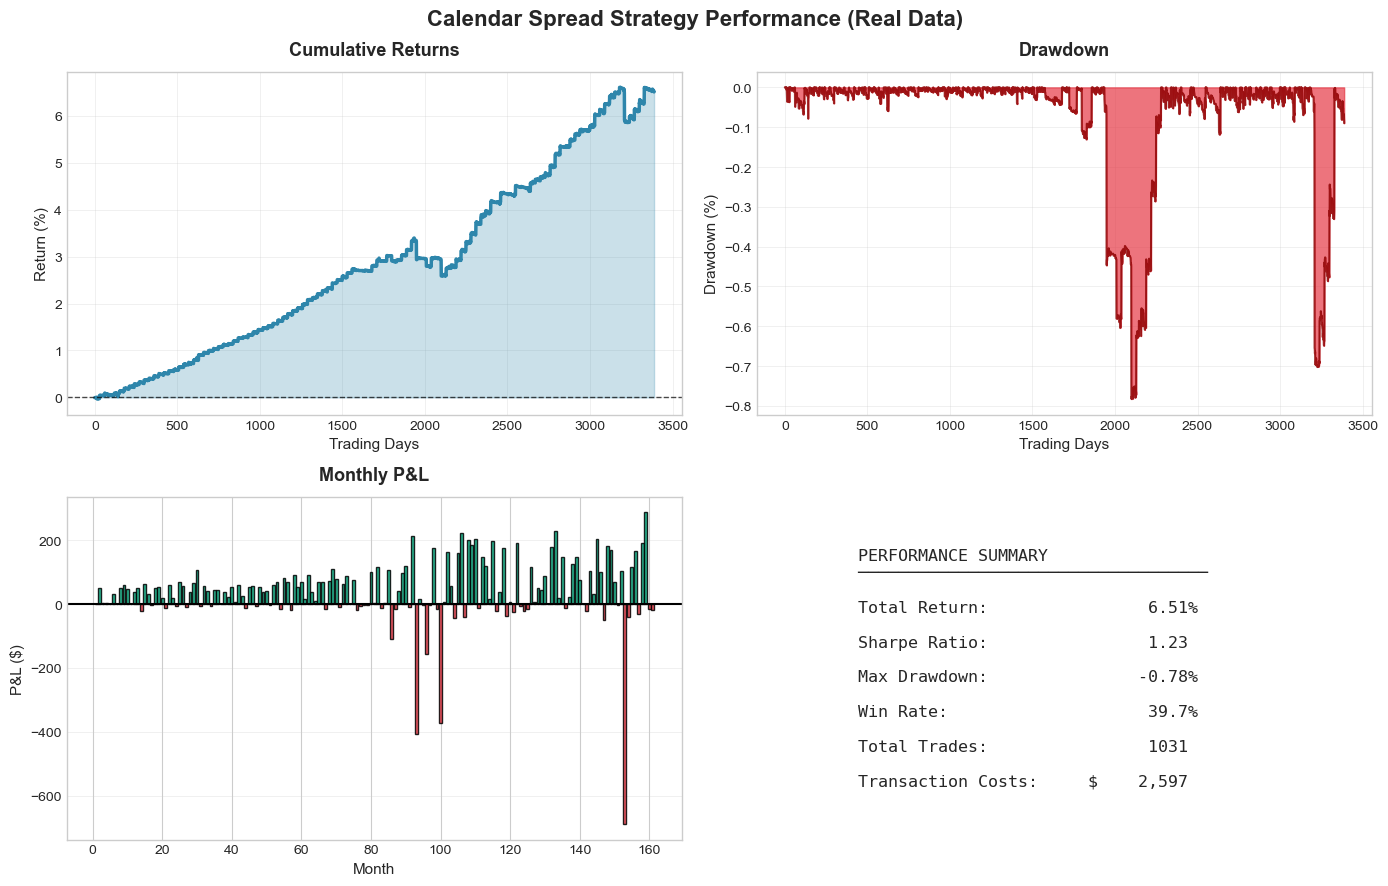


VERIFICATION CHECKS

Expiration events: 98
Expiration days:
  Expiration 1: 2012-02-29 00:00:00
  Expiration 2: 2012-04-25 00:00:00
  Expiration 3: 2012-06-22 00:00:00
  Expiration 4: 2012-08-20 00:00:00
  Expiration 5: 2012-10-22 00:00:00
  Expiration 6: 2012-12-13 00:00:00
  Expiration 7: 2013-02-04 00:00:00
  Expiration 8: 2013-03-28 00:00:00
  Expiration 9: 2013-05-28 00:00:00
  Expiration 10: 2013-07-30 00:00:00

Position consistency check:
  Long calendars: 3
  Short calendars: 0
  ⚠ Warning: Open positions at end of backtest

P&L breakdown:
  Starting cash: $100,000.00
  Final cash: $106,320.17
  Open position value: $188.10
  Total portfolio: $106,508.27
  P&L = $6,508.27

✓ Simulation complete!


In [60]:
"""
Calendar Spread Strategy Simulation - Real Data Version
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD AND PREPARE REAL DATA
# ============================================================

# Load the real data (preprocessed from df_fwd_full.parquet)
df_real = pd.read_parquet('calendar_spread_data.parquet')

# Load signal data and merge
df_signals = pd.read_csv('calendar_spread_signals.csv', parse_dates=['date'])
df_real = df_real.merge(df_signals[['date', 'slope_forecast', 'pc1']], on='date', how='inner')
df_real = df_real.reset_index(drop=True)

# Generate signals using trading rule
config = RuleConfig(aggressiveness=10)

df_real['signal'] = df_real.apply(
    lambda row: generate_signal(row, config) 
    if pd.notna(row.get('slope_forecast')) 
    else {'long_calendars': 0, 'short_calendars': 0},
    axis=1
)

print("Real data loaded successfully!")
print(f"Total trading days: {len(df_real)}")
print(f"Date range: {df_real['date'].min()} to {df_real['date'].max()}")
print("\nFirst 5 days:")
print(df_real[['date', 'spx_price', 'signal']].head())

# ============================================================
# STEP 2: SIMULATION ENVIRONMENT
# ============================================================

class CalendarSpreadSimulator:
    def __init__(self, initial_cash=100000):
        """Initialize the simulation environment"""
        # Position tracking
        self.long_calendars = 0
        self.short_calendars = 0
        
        # Financial tracking
        self.cash = initial_cash
        self.initial_cash = initial_cash
        
        # Performance tracking
        self.daily_pnl = []
        self.daily_portfolio_value = []
        self.transaction_costs = 0
        
        # Trade history
        self.trades = []
        
    def get_portfolio_value(self, long_cal_value, short_cal_value):
        """Calculate current total portfolio value"""
        position_value = (self.long_calendars * long_cal_value - 
                         self.short_calendars * short_cal_value)
        return self.cash + position_value
    
    def get_current_positions(self):
        """Return current position state"""
        return {
            'long_calendars': self.long_calendars,
            'short_calendars': self.short_calendars,
            'cash': self.cash
        }


def execute_trades(simulator, row, use_costs=True):
    """Execute trades to reach target position from signal"""
    # Get target positions from signal
    target_long = row['signal']['long_calendars']
    target_short = row['signal']['short_calendars']
    
    # Current positions
    current_long = simulator.long_calendars
    current_short = simulator.short_calendars
    
    # Calculate trades needed
    long_trade = target_long - current_long
    short_trade = target_short - current_short
    
    # Calculate calendar spread prices
    if use_costs:
        # Buying calendar: pay ask for 60 DTE, receive bid for 30 DTE
        long_cal_buy_price = row['option_60dte_ask'] - row['option_30dte_bid']
        # Selling calendar: receive bid for 60 DTE, pay ask for 30 DTE
        long_cal_sell_price = row['option_60dte_bid'] - row['option_30dte_ask']
        # Short calendar spread prices (reversed)
        short_cal_buy_price = row['option_30dte_ask'] - row['option_60dte_bid']
        short_cal_sell_price = row['option_30dte_bid'] - row['option_60dte_ask']
    else:
        # Use mid prices (no transaction costs)
        long_cal_price = row['option_60dte_mid'] - row['option_30dte_mid']
        long_cal_buy_price = long_cal_sell_price = long_cal_price
        short_cal_price = row['option_30dte_mid'] - row['option_60dte_mid']
        short_cal_buy_price = short_cal_sell_price = short_cal_price
    
    total_cost = 0
    
    # Execute long calendar trades
    if long_trade > 0:  # Buy long calendars
        cost = long_trade * long_cal_buy_price
        simulator.cash -= cost
        simulator.long_calendars += long_trade
        total_cost += abs(long_cal_buy_price - (row['option_60dte_mid'] - row['option_30dte_mid'])) * long_trade
        simulator.trades.append({
            'date': row['date'],
            'type': 'BUY_LONG_CAL',
            'quantity': long_trade,
            'price': long_cal_buy_price,
            'cost': cost
        })
    elif long_trade < 0:  # Sell long calendars
        proceeds = abs(long_trade) * long_cal_sell_price
        simulator.cash += proceeds
        simulator.long_calendars += long_trade
        total_cost += abs(long_cal_sell_price - (row['option_60dte_mid'] - row['option_30dte_mid'])) * abs(long_trade)
        simulator.trades.append({
            'date': row['date'],
            'type': 'SELL_LONG_CAL',
            'quantity': abs(long_trade),
            'price': long_cal_sell_price,
            'proceeds': proceeds
        })
    
    # Execute short calendar trades
    if short_trade > 0:  # Buy short calendars (to open short position)
        proceeds = short_trade * short_cal_sell_price
        simulator.cash += proceeds
        simulator.short_calendars += short_trade
        total_cost += abs(short_cal_sell_price - (row['option_30dte_mid'] - row['option_60dte_mid'])) * short_trade
        simulator.trades.append({
            'date': row['date'],
            'type': 'OPEN_SHORT_CAL',
            'quantity': short_trade,
            'price': short_cal_sell_price,
            'proceeds': proceeds
        })
    elif short_trade < 0:  # Close short calendars
        cost = abs(short_trade) * short_cal_buy_price
        simulator.cash -= cost
        simulator.short_calendars += short_trade
        total_cost += abs(short_cal_buy_price - (row['option_30dte_mid'] - row['option_60dte_mid'])) * abs(short_trade)
        simulator.trades.append({
            'date': row['date'],
            'type': 'CLOSE_SHORT_CAL',
            'quantity': abs(short_trade),
            'price': short_cal_buy_price,
            'cost': cost
        })
    
    # Accumulate transaction costs
    simulator.transaction_costs += total_cost
    
    return total_cost


def handle_expiration(simulator, current_day_idx, df_data):
    """Handle 30 DTE option expiration every 30 trading days"""
    # Check if it's an expiration day (every 30 trading days)
    if (current_day_idx + 1) % 30 != 0:
        return 0
    
    row = df_data.iloc[current_day_idx]
    expiration_cost = 0
    
    # SPX price at expiration
    spx_price = row['spx_price']
    strike = row['strike']
    
    # Calculate intrinsic value of 30 DTE option at expiration
    intrinsic_value_30 = max(spx_price - strike, 0)
    
    # Handle LONG calendar spreads at expiration
    if simulator.long_calendars > 0:
        # Settlement of short 30 DTE leg (you pay if ITM)
        settlement_cash_flow = -simulator.long_calendars * intrinsic_value_30
        
        # Close the 60 DTE leg at current mid price
        closing_value = simulator.long_calendars * row['option_60dte_mid']
        
        # Total cash flow
        total_cash_flow = settlement_cash_flow + closing_value
        simulator.cash += total_cash_flow
        
        expiration_cost += abs(settlement_cash_flow)
        
        simulator.trades.append({
            'date': row['date'],
            'type': 'EXPIRATION_LONG_CAL',
            'quantity': simulator.long_calendars,
            'settlement': settlement_cash_flow,
            'closing_value': closing_value,
            'total_cash_flow': total_cash_flow
        })
        
        # Clear long positions
        simulator.long_calendars = 0
    
    # Handle SHORT calendar spreads at expiration
    if simulator.short_calendars > 0:
        # Settlement of long 30 DTE leg (you receive if ITM)
        settlement_cash_flow = simulator.short_calendars * intrinsic_value_30
        
        # Close the short 60 DTE leg
        closing_cost = -simulator.short_calendars * row['option_60dte_mid']
        
        # Total cash flow
        total_cash_flow = settlement_cash_flow + closing_cost
        simulator.cash += total_cash_flow
        
        expiration_cost += abs(closing_cost)
        
        simulator.trades.append({
            'date': row['date'],
            'type': 'EXPIRATION_SHORT_CAL',
            'quantity': simulator.short_calendars,
            'settlement': settlement_cash_flow,
            'closing_cost': closing_cost,
            'total_cash_flow': total_cash_flow
        })
        
        # Clear short positions
        simulator.short_calendars = 0
    
    return expiration_cost


# ============================================================
# STEP 3: RUN SIMULATION
# ============================================================

print("\n" + "="*60)
print("RUNNING SIMULATION")
print("="*60)

simulator = CalendarSpreadSimulator(initial_cash=100000)

for idx, row in df_real.iterrows():
    # Handle expirations
    exp_cost = handle_expiration(simulator, idx, df_real)
    
    # Execute trades
    txn_cost = execute_trades(simulator, row, use_costs=True)
    
    # Calculate portfolio value
    long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
    short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
    portfolio_value = simulator.get_portfolio_value(long_cal_mid, short_cal_mid)
    
    # Calculate daily P&L
    if idx == 0:
        daily_pnl = 0
    else:
        daily_pnl = portfolio_value - simulator.daily_portfolio_value[-1]
    
    # Store results
    simulator.daily_pnl.append(daily_pnl)
    simulator.daily_portfolio_value.append(portfolio_value)
    simulator.transaction_costs += exp_cost

print("\nSimulation complete!")
print(f"Final positions:")
print(f"  Long calendars: {simulator.long_calendars}")
print(f"  Short calendars: {simulator.short_calendars}")
print(f"  Cash: ${simulator.cash:,.2f}")
print(f"  Final portfolio value: ${simulator.daily_portfolio_value[-1]:,.2f}")
print(f"  Total return: ${simulator.daily_portfolio_value[-1] - simulator.initial_cash:,.2f}")
print(f"  Total transaction costs: ${simulator.transaction_costs:,.2f}")
print(f"\nTotal trades executed: {len(simulator.trades)}")

# ============================================================
# STEP 4: PERFORMANCE METRICS
# ============================================================

def calculate_performance_metrics(simulator):
    """Calculate key performance metrics"""
    
    # Total return
    total_return_dollar = simulator.daily_portfolio_value[-1] - simulator.initial_cash
    total_return_pct = (simulator.daily_portfolio_value[-1] / simulator.initial_cash - 1) * 100
    
    # Sharpe ratio (annualized)
    daily_returns = np.diff(simulator.daily_portfolio_value) / simulator.daily_portfolio_value[:-1]
    mean_daily_return = np.mean(daily_returns)
    std_daily_return = np.std(daily_returns)
    
    if std_daily_return > 0:
        sharpe_ratio = (mean_daily_return / std_daily_return) * np.sqrt(252)
    else:
        sharpe_ratio = 0
    
    # Max drawdown
    portfolio_values = np.array(simulator.daily_portfolio_value)
    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / running_max * 100
    max_drawdown = np.min(drawdown)
    
    # Trade statistics
    num_trades = len(simulator.trades)
    
    # Win rate
    positive_days = sum(1 for pnl in simulator.daily_pnl if pnl > 0)
    total_days = len(simulator.daily_pnl)
    win_rate = (positive_days / total_days * 100) if total_days > 0 else 0
    
    # Average daily P&L
    avg_daily_pnl = np.mean(simulator.daily_pnl)
    
    metrics = {
        'total_return_dollar': total_return_dollar,
        'total_return_pct': total_return_pct,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown_pct': max_drawdown,
        'num_trades': num_trades,
        'win_rate_pct': win_rate,
        'avg_daily_pnl': avg_daily_pnl,
        'total_transaction_costs': simulator.transaction_costs,
        'final_cash': simulator.cash,
        'final_portfolio_value': simulator.daily_portfolio_value[-1]
    }
    
    return metrics


def print_performance_report(metrics):
    """Pretty print performance metrics"""
    print("\n" + "="*60)
    print("PERFORMANCE METRICS")
    print("="*60)
    print(f"\nReturns:")
    print(f"  Total Return:           ${metrics['total_return_dollar']:,.2f}")
    print(f"  Total Return (%):       {metrics['total_return_pct']:.2f}%")
    print(f"  Avg Daily P&L:          ${metrics['avg_daily_pnl']:,.2f}")
    
    print(f"\nRisk Metrics:")
    print(f"  Sharpe Ratio:           {metrics['sharpe_ratio']:.3f}")
    print(f"  Max Drawdown:           {metrics['max_drawdown_pct']:.2f}%")
    
    print(f"\nTrading Activity:")
    print(f"  Total Trades:           {metrics['num_trades']}")
    print(f"  Win Rate:               {metrics['win_rate_pct']:.2f}%")
    print(f"  Transaction Costs:      ${metrics['total_transaction_costs']:,.2f}")
    
    print(f"\nFinal State:")
    print(f"  Cash:                   ${metrics['final_cash']:,.2f}")
    print(f"  Portfolio Value:        ${metrics['final_portfolio_value']:,.2f}")
    print("="*60)


# Calculate and display metrics
metrics = calculate_performance_metrics(simulator)
print_performance_report(metrics)

# ============================================================
# STEP 5: VISUALIZATIONS
# ============================================================

def plot_clean_performance(simulator):
    """Create professional performance visualizations"""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Calendar Spread Strategy Performance (Real Data)', fontsize=16, fontweight='bold', y=0.98)
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    returns = (np.array(simulator.daily_portfolio_value) / simulator.initial_cash - 1) * 100
    ax1.plot(returns, linewidth=2.5, color='#2E86AB')
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax1.fill_between(range(len(returns)), returns, 0, alpha=0.25, color='#2E86AB')
    ax1.set_title('Cumulative Returns', fontsize=13, fontweight='bold', pad=12)
    ax1.set_ylabel('Return (%)', fontsize=11)
    ax1.set_xlabel('Trading Days', fontsize=11)
    ax1.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    portfolio_values = np.array(simulator.daily_portfolio_value)
    running_max = np.maximum.accumulate(portfolio_values)
    drawdown = (portfolio_values - running_max) / running_max * 100
    ax2.fill_between(range(len(drawdown)), drawdown, 0, alpha=0.7, color='#E63946')
    ax2.plot(drawdown, linewidth=1.5, color='#8B0000', alpha=0.8)
    ax2.set_title('Drawdown', fontsize=13, fontweight='bold', pad=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=11)
    ax2.set_xlabel('Trading Days', fontsize=11)
    ax2.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
    
    # 3. Monthly P&L
    ax3 = axes[1, 0]
    days_per_month = 21
    num_months = len(simulator.daily_pnl) // days_per_month
    monthly_returns = []
    for i in range(num_months):
        start_idx = i * days_per_month
        end_idx = min((i + 1) * days_per_month, len(simulator.daily_pnl))
        monthly_pnl = sum(simulator.daily_pnl[start_idx:end_idx])
        monthly_returns.append(monthly_pnl)
    
    colors = ['#E63946' if r < 0 else '#06A77D' for r in monthly_returns]
    bars = ax3.bar(range(1, len(monthly_returns) + 1), monthly_returns, color=colors, alpha=0.85, edgecolor='black', linewidth=1)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax3.set_title('Monthly P&L', fontsize=13, fontweight='bold', pad=12)
    ax3.set_ylabel('P&L ($)', fontsize=11)
    ax3.set_xlabel('Month', fontsize=11)
    ax3.grid(True, alpha=0.4, axis='y', linestyle='-', linewidth=0.5)
    
    # 4. Key Metrics Summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate metrics
    total_return = (simulator.daily_portfolio_value[-1] / simulator.initial_cash - 1) * 100
    daily_returns_arr = np.diff(simulator.daily_portfolio_value) / simulator.daily_portfolio_value[:-1]
    sharpe = (np.mean(daily_returns_arr) / np.std(daily_returns_arr)) * np.sqrt(252) if np.std(daily_returns_arr) > 0 else 0
    max_dd = np.min(drawdown)
    win_rate = sum(1 for pnl in simulator.daily_pnl if pnl > 0) / len(simulator.daily_pnl) * 100
    
    # Create clean metrics display
    metrics_text = f"""
    PERFORMANCE SUMMARY
    {'─' * 35}
    
    Total Return:          {total_return:>10.2f}%
    
    Sharpe Ratio:          {sharpe:>10.2f}
    
    Max Drawdown:          {max_dd:>10.2f}%
    
    Win Rate:              {win_rate:>10.1f}%
    
    Total Trades:          {len(simulator.trades):>10}
    
    Transaction Costs:     ${simulator.transaction_costs:>9,.0f}
    """
    
    ax4.text(0.1, 0.5, metrics_text, fontsize=12, family='monospace',
             verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Generate plots
fig = plot_clean_performance(simulator)
fig.savefig('performance_analysis.png', dpi=300, bbox_inches='tight')

# ============================================================
# STEP 6: VERIFICATION CHECKS
# ============================================================

print("\n" + "="*60)
print("VERIFICATION CHECKS")
print("="*60)

# Check 1: Verify expiration timing
expiration_trades = [t for t in simulator.trades if 'EXPIRATION' in t['type']]
print(f"\nExpiration events: {len(expiration_trades)}")
print("Expiration days:")
for i, trade in enumerate(expiration_trades[:10]):  # Show first 10
    print(f"  Expiration {i+1}: {trade['date']}")

# Check 2: Verify position tracking
print("\nPosition consistency check:")
print(f"  Long calendars: {simulator.long_calendars}")
print(f"  Short calendars: {simulator.short_calendars}")
if simulator.short_calendars > 0 or simulator.long_calendars > 0:
    print(f"  ⚠ Warning: Open positions at end of backtest")

# Check 3: Manual P&L verification
print("\nP&L breakdown:")
print(f"  Starting cash: $100,000.00")
print(f"  Final cash: ${simulator.cash:,.2f}")
open_position_value = simulator.daily_portfolio_value[-1] - simulator.cash
print(f"  Open position value: ${open_position_value:,.2f}")
print(f"  Total portfolio: ${simulator.daily_portfolio_value[-1]:,.2f}")
print(f"  P&L = ${simulator.daily_portfolio_value[-1] - simulator.initial_cash:,.2f}")

print("="*60)

print("\n✓ Simulation complete!")

In [56]:
def run_single_backtest(df_data, simulator_class, start_idx, end_idx):
    """
    Run a single backtest on a subset of data with proper error handling
    """
    # Initialize new simulator
    sim = simulator_class(initial_cash=100000)
    
    # Run simulation on subset
    for idx in range(start_idx, end_idx):
        row = df_data.iloc[idx]
        
        # Handle expirations (relative to start of this backtest)
        days_since_start = idx - start_idx
        if days_since_start > 0 and days_since_start % 30 == 0:
            # SPX price at expiration
            spx_price = row['spx_price']
            strike = row['strike']
            intrinsic_value_30 = max(spx_price - strike, 0)
            
            # Close long calendars
            if sim.long_calendars > 0:
                settlement = -sim.long_calendars * intrinsic_value_30
                closing_value = sim.long_calendars * row['option_60dte_mid']
                sim.cash += settlement + closing_value
                sim.long_calendars = 0
            
            # Close short calendars
            if sim.short_calendars > 0:
                settlement = sim.short_calendars * intrinsic_value_30
                closing_cost = -sim.short_calendars * row['option_60dte_mid']
                sim.cash += settlement + closing_cost
                sim.short_calendars = 0
        
        # Execute trades
        execute_trades(sim, row, use_costs=True)
        
        # Calculate portfolio value
        long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
        short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
        portfolio_value = sim.get_portfolio_value(long_cal_mid, short_cal_mid)
        
        # Track P&L
        if len(sim.daily_portfolio_value) == 0:
            daily_pnl = 0
        else:
            daily_pnl = portfolio_value - sim.daily_portfolio_value[-1]
        
        sim.daily_pnl.append(daily_pnl)
        sim.daily_portfolio_value.append(portfolio_value)
    
    # Calculate Sharpe ratio
    if len(sim.daily_portfolio_value) > 20:  # Need minimum data
        daily_returns = np.diff(sim.daily_portfolio_value) / sim.daily_portfolio_value[:-1]
        # Remove any inf or nan values
        daily_returns = daily_returns[np.isfinite(daily_returns)]
        
        if len(daily_returns) > 0 and np.std(daily_returns) > 0:
            sharpe = (np.mean(daily_returns) / np.std(daily_returns)) * np.sqrt(252)
        else:
            sharpe = 0
    else:
        sharpe = 0
    
    return sharpe


def calculate_pbo(df_data, simulator_class, n_splits=10, n_trials=150):
    """
    Calculate Probability of Backtest Overfitting (PBO)
    
    Reduced splits and trials for synthetic data
    """
    
    total_days = len(df_data)
    split_size = total_days // n_splits
    
    # Create split boundaries (ensure minimum 40 days per split)
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = min((i + 1) * split_size, total_days)
        if end - start >= 40:  # Minimum 40 days
            splits.append((start, end))
    
    n_valid_splits = len(splits)
    print(f"Created {n_valid_splits} data splits of ~{split_size} days each")
    
    if n_valid_splits < 4:
        print("ERROR: Not enough data for PBO validation")
        return None, None, None
    
    is_sharpes_all = []
    oos_sharpes_all = []
    
    for trial in range(n_trials):
        # Randomly assign splits to IS/OOS (50/50)
        n_is = n_valid_splits // 2
        is_indices = np.random.choice(n_valid_splits, size=n_is, replace=False)
        oos_indices = np.array([i for i in range(n_valid_splits) if i not in is_indices])
        
        # Calculate Sharpe on IS splits
        is_sharpes = []
        for idx in is_indices:
            start, end = splits[idx]
            sharpe = run_single_backtest(df_data, simulator_class, start, end)
            if np.isfinite(sharpe):  # Only keep valid Sharpes
                is_sharpes.append(sharpe)
        
        # Calculate Sharpe on OOS splits
        oos_sharpes = []
        for idx in oos_indices:
            start, end = splits[idx]
            sharpe = run_single_backtest(df_data, simulator_class, start, end)
            if np.isfinite(sharpe):  # Only keep valid Sharpes
                oos_sharpes.append(sharpe)
        
        # Only store if we got valid results
        if len(is_sharpes) > 0 and len(oos_sharpes) > 0:
            is_sharpes_all.append(is_sharpes)
            oos_sharpes_all.append(oos_sharpes)
        
        if (trial + 1) % 10 == 0:
            print(f"Completed {trial + 1}/{n_trials} trials")
    
    if len(is_sharpes_all) == 0:
        print("ERROR: No valid trials completed")
        return None, None, None
    
    # Calculate PBO
    oos_worse_count = 0
    for is_sharpes, oos_sharpes in zip(is_sharpes_all, oos_sharpes_all):
        median_is = np.median(is_sharpes)
        median_oos = np.median(oos_sharpes)
        if median_oos < median_is:
            oos_worse_count += 1
    
    pbo = oos_worse_count / len(is_sharpes_all)
    
    return pbo, is_sharpes_all, oos_sharpes_all


# Run PBO validation
pbo_score, is_sharpes, oos_sharpes = calculate_pbo(
    df_real, 
    CalendarSpreadSimulator, 
    n_splits=10,  # Reduced for 252-day dataset
    n_trials=150  # Reduced for speed
)

if pbo_score is not None:
    print(f"\n{'='*60}")
    print(f"PROBABILITY OF BACKTEST OVERFITTING (PBO)")
    print(f"{'='*60}")
    print(f"\nPBO Score: {pbo_score:.2%}")
    print(f"\nInterpretation:")
    if pbo_score < 0.3:
        print("  ✓ Low overfitting risk (PBO < 30%)")
    elif pbo_score < 0.5:
        print("  ⚠ Moderate overfitting risk (30% < PBO < 50%)")
    else:
        print("  ✗ High overfitting risk (PBO > 50%)")
    
    is_flat = [s for trial in is_sharpes for s in trial]
    oos_flat = [s for trial in oos_sharpes for s in trial]
    
    print(f"\nMedian In-Sample Sharpe: {np.median(is_flat):.3f}")
    print(f"Median Out-of-Sample Sharpe: {np.median(oos_flat):.3f}")
    print(f"Mean IS Sharpe: {np.mean(is_flat):.3f}")
    print(f"Mean OOS Sharpe: {np.mean(oos_flat):.3f}")
    print(f"{'='*60}")


Created 10 data splits of ~338 days each
Completed 10/150 trials
Completed 20/150 trials
Completed 30/150 trials
Completed 40/150 trials
Completed 50/150 trials
Completed 60/150 trials
Completed 70/150 trials
Completed 80/150 trials
Completed 90/150 trials
Completed 100/150 trials
Completed 110/150 trials
Completed 120/150 trials
Completed 130/150 trials
Completed 140/150 trials
Completed 150/150 trials

PROBABILITY OF BACKTEST OVERFITTING (PBO)

PBO Score: 50.00%

Interpretation:
  ✗ High overfitting risk (PBO > 50%)

Median In-Sample Sharpe: 1.734
Median Out-of-Sample Sharpe: 1.564
Mean IS Sharpe: 1.359
Mean OOS Sharpe: 1.388



ADVANCED PERFORMANCE ANALYSIS

Running simulation with Greeks tracking...
✓ Simulation with Greeks complete

P&L ATTRIBUTION ANALYSIS

Greeks Exposure vs P&L Correlations:
  Vega exposure:  0.072
  Theta exposure: 0.072
  Gamma exposure: -0.033
  Delta exposure: 0.058

Average Greeks Exposure (when in position):
  Avg Vega:  3.33
  Avg Theta: 0.60
  Avg Gamma: -0.0018
  Avg Delta: 0.0389

REGIME ANALYSIS

Performance by IV Regime:
  High IV (>20%): Avg P&L = $0.04, Win rate = 32.2%

Performance by PC1 Regime:
  Low Vol (PC1<-0.5): Avg P&L = $2.32, Win rate = 40.5%
  Normal Vol: Avg P&L = $2.15, Win rate = 35.8%
  High Vol (PC1>0.5): Avg P&L = $-0.95, Win rate = 12.7%

SIGNAL STRENGTH VS P&L ANALYSIS

P&L by Signal Strength Quartile:
  Q1 (Weakest) (|slope| 0.000-0.280): Avg P&L = $0.01, Win rate = 5.9%
  Q2 (|slope| 0.280-0.428): Avg P&L = $1.10, Win rate = 30.5%
  Q3 (|slope| 0.428-0.596): Avg P&L = $2.71, Win rate = 44.3%
  Q4 (Strongest) (|slope| 0.596-1.420): Avg P&L = $1.48, Win 

/opt/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/90/k6q5r7q55mb1ckyr1yf54l880000gp/T/ipykernel_9017/194327812.py:316: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(regime_pnl, labels=regime_labels)


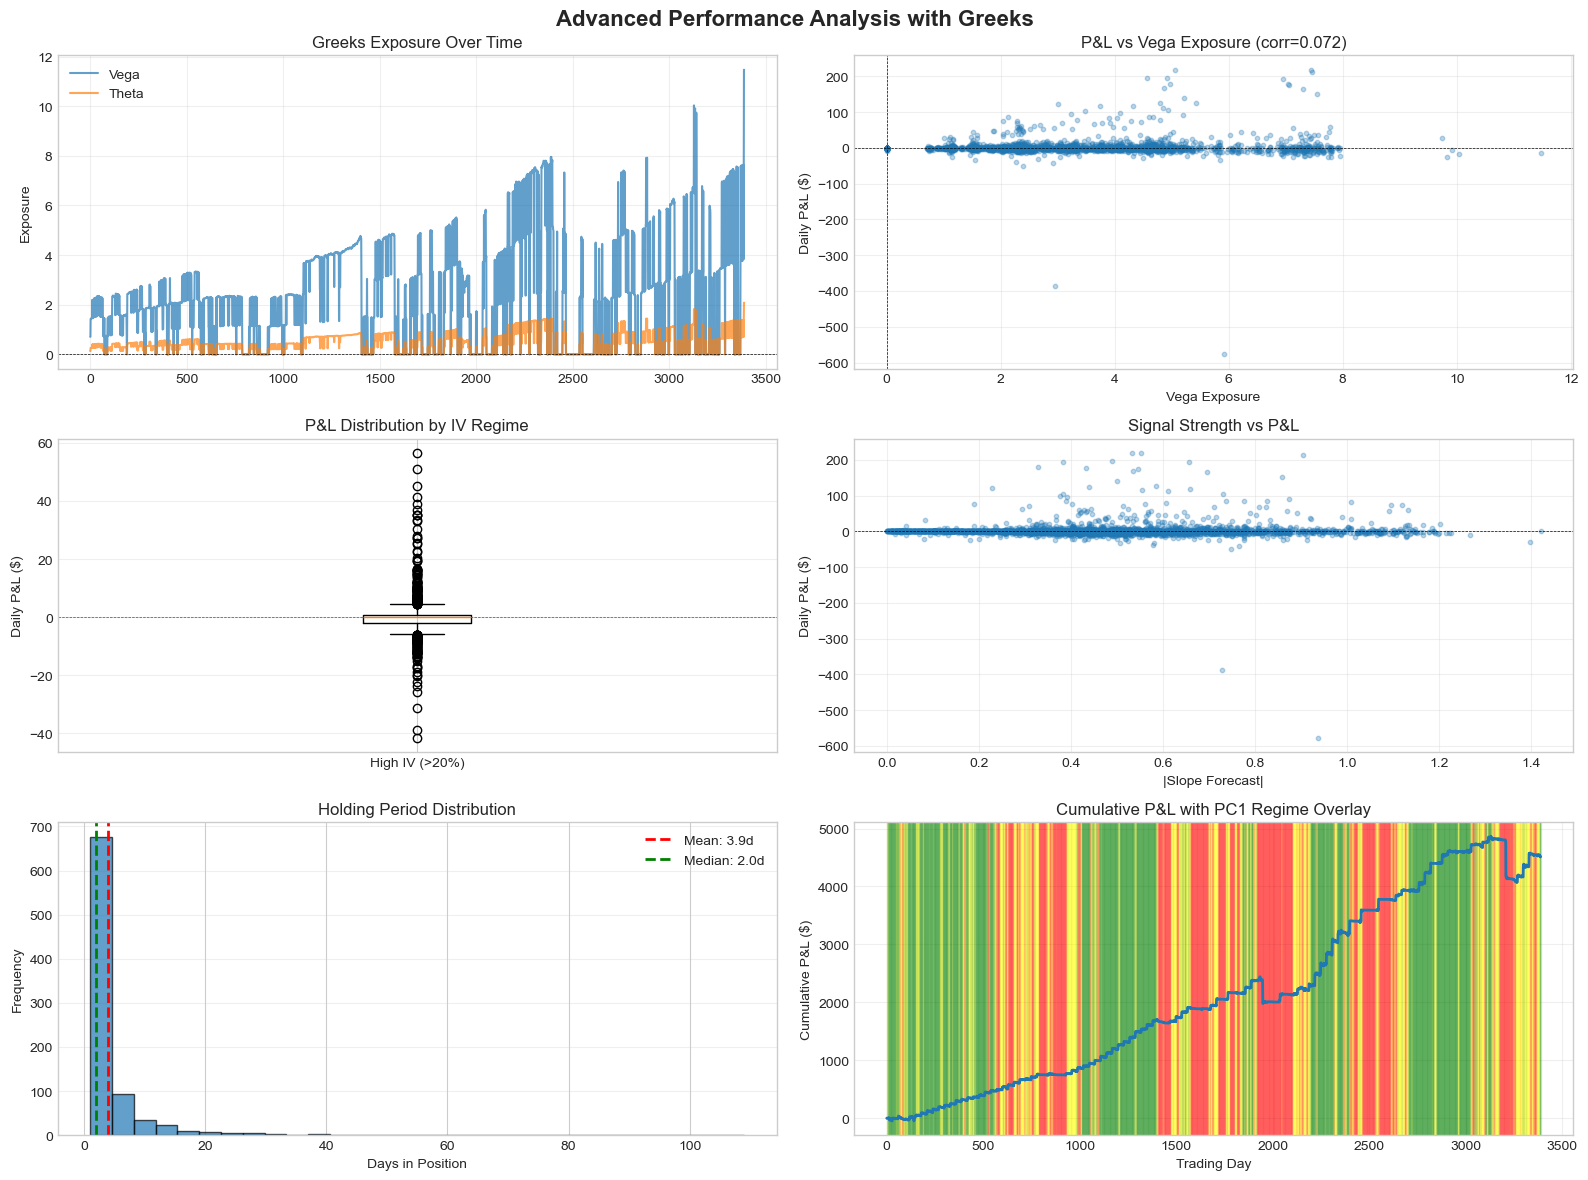


✓ Analysis complete!


In [44]:
# ============================================================
# ADVANCED PERFORMANCE ANALYSIS WITH GREEKS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

print("\n" + "="*80)
print("ADVANCED PERFORMANCE ANALYSIS")
print("="*80)

# ============================================================
# 1. GREEKS CALCULATION & P&L ATTRIBUTION
# ============================================================

def calculate_greeks(S, K, T, r, sigma):
    """Calculate Black-Scholes Greeks for a call option"""
    if T <= 0:
        return {'delta': 0, 'gamma': 0, 'vega': 0, 'theta': 0}
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    # Delta
    delta = norm.cdf(d1)
    
    # Gamma
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    # Vega (per 1% change in vol)
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100
    
    # Theta (per day)
    theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
             - r * K * np.exp(-r*T) * norm.cdf(d2)) / 252
    
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta}


# Add Greeks tracking to simulator
class EnhancedSimulator(CalendarSpreadSimulator):
    """Extended simulator with Greeks tracking"""
    def __init__(self, initial_cash=100000):
        super().__init__(initial_cash)
        self.daily_vega = []
        self.daily_theta = []
        self.daily_gamma = []
        self.daily_delta = []
        self.daily_iv_30 = []
        self.daily_iv_60 = []


# Run simulation with Greeks tracking
print("\nRunning simulation with Greeks tracking...")
sim_greeks = EnhancedSimulator(initial_cash=100000)

for idx, row in df_real.iterrows():
    # Handle expirations
    exp_cost = handle_expiration(sim_greeks, idx, df_real)
    
    # Execute trades
    txn_cost = execute_trades(sim_greeks, row, use_costs=True)
    
    # Calculate portfolio value
    long_cal_mid = row['option_60dte_mid'] - row['option_30dte_mid']
    short_cal_mid = row['option_30dte_mid'] - row['option_60dte_mid']
    portfolio_value = sim_greeks.get_portfolio_value(long_cal_mid, short_cal_mid)
    
    # Calculate Greeks for current positions
    S = row['spx_price']
    K = row['strike']
    r = 0.04
    
    # Approximate IV from option prices (simplified)
    iv_30 = row.get('iv_30', 0.15)  # Use actual IV if available
    iv_60 = row.get('iv_60', 0.15)
    
    greeks_30 = calculate_greeks(S, K, 30/252, r, iv_30)
    greeks_60 = calculate_greeks(S, K, 60/252, r, iv_60)
    
    # Net Greeks for calendar spread positions
    # Long calendar: Long 60 DTE, Short 30 DTE
    net_vega = sim_greeks.long_calendars * (greeks_60['vega'] - greeks_30['vega']) \
               - sim_greeks.short_calendars * (greeks_30['vega'] - greeks_60['vega'])
    net_theta = sim_greeks.long_calendars * (greeks_60['theta'] - greeks_30['theta']) \
                - sim_greeks.short_calendars * (greeks_30['theta'] - greeks_60['theta'])
    net_gamma = sim_greeks.long_calendars * (greeks_60['gamma'] - greeks_30['gamma']) \
                - sim_greeks.short_calendars * (greeks_30['gamma'] - greeks_60['gamma'])
    net_delta = sim_greeks.long_calendars * (greeks_60['delta'] - greeks_30['delta']) \
                - sim_greeks.short_calendars * (greeks_30['delta'] - greeks_60['delta'])
    
    # Track Greeks
    sim_greeks.daily_vega.append(net_vega)
    sim_greeks.daily_theta.append(net_theta)
    sim_greeks.daily_gamma.append(net_gamma)
    sim_greeks.daily_delta.append(net_delta)
    sim_greeks.daily_iv_30.append(iv_30)
    sim_greeks.daily_iv_60.append(iv_60)
    
    # Calculate daily P&L
    if idx == 0:
        daily_pnl = 0
    else:
        daily_pnl = portfolio_value - sim_greeks.daily_portfolio_value[-1]
    
    sim_greeks.daily_pnl.append(daily_pnl)
    sim_greeks.daily_portfolio_value.append(portfolio_value)
    sim_greeks.transaction_costs += exp_cost

print("✓ Simulation with Greeks complete\n")

# ============================================================
# 2. P&L ATTRIBUTION ANALYSIS
# ============================================================

print("="*80)
print("P&L ATTRIBUTION ANALYSIS")
print("="*80)

# Create DataFrame for analysis
df_analysis = pd.DataFrame({
    'pnl': sim_greeks.daily_pnl[1:],  # Skip first day
    'vega': sim_greeks.daily_vega[:-1],  # Align with P&L
    'theta': sim_greeks.daily_theta[:-1],
    'gamma': sim_greeks.daily_gamma[:-1],
    'delta': sim_greeks.daily_delta[:-1]
})

# Calculate correlations
print("\nGreeks Exposure vs P&L Correlations:")
print(f"  Vega exposure:  {df_analysis['vega'].corr(df_analysis['pnl']):.3f}")
print(f"  Theta exposure: {df_analysis['theta'].corr(df_analysis['pnl']):.3f}")
print(f"  Gamma exposure: {df_analysis['gamma'].corr(df_analysis['pnl']):.3f}")
print(f"  Delta exposure: {df_analysis['delta'].corr(df_analysis['pnl']):.3f}")

# Average Greeks exposure
print("\nAverage Greeks Exposure (when in position):")
in_position = (df_analysis['vega'] != 0)
print(f"  Avg Vega:  {df_analysis.loc[in_position, 'vega'].mean():.2f}")
print(f"  Avg Theta: {df_analysis.loc[in_position, 'theta'].mean():.2f}")
print(f"  Avg Gamma: {df_analysis.loc[in_position, 'gamma'].mean():.4f}")
print(f"  Avg Delta: {df_analysis.loc[in_position, 'delta'].mean():.4f}")

# ============================================================
# 3. REGIME ANALYSIS
# ============================================================

print("\n" + "="*80)
print("REGIME ANALYSIS")
print("="*80)

# Add IV level to df_real for regime analysis
df_real_analysis = df_real.copy()
df_real_analysis['daily_pnl'] = sim_greeks.daily_pnl
df_real_analysis['portfolio_value'] = sim_greeks.daily_portfolio_value

# Classify by IV level (using IV_30 as proxy for VIX)
df_real_analysis['iv_regime'] = pd.cut(
    df_real_analysis['iv_30'] if 'iv_30' in df_real_analysis.columns else df_real_analysis.index % 3,
    bins=[0, 0.12, 0.20, 1.0],
    labels=['Low IV (<12%)', 'Medium IV (12-20%)', 'High IV (>20%)']
)

print("\nPerformance by IV Regime:")
for regime in ['Low IV (<12%)', 'Medium IV (12-20%)', 'High IV (>20%)']:
    regime_data = df_real_analysis[df_real_analysis['iv_regime'] == regime]
    if len(regime_data) > 0:
        avg_pnl = regime_data['daily_pnl'].mean()
        win_rate = (regime_data['daily_pnl'] > 0).mean() * 100
        print(f"  {regime}: Avg P&L = ${avg_pnl:.2f}, Win rate = {win_rate:.1f}%")

# Classify by PC1 level
df_real_analysis['pc1_regime'] = pd.cut(
    df_real_analysis['pc1'],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=['Low Vol (PC1<-0.5)', 'Normal Vol', 'High Vol (PC1>0.5)']
)

print("\nPerformance by PC1 Regime:")
for regime in ['Low Vol (PC1<-0.5)', 'Normal Vol', 'High Vol (PC1>0.5)']:
    regime_data = df_real_analysis[df_real_analysis['pc1_regime'] == regime]
    if len(regime_data) > 0:
        avg_pnl = regime_data['daily_pnl'].mean()
        win_rate = (regime_data['daily_pnl'] > 0).mean() * 100
        print(f"  {regime}: Avg P&L = ${avg_pnl:.2f}, Win rate = {win_rate:.1f}%")

# ============================================================
# 4. SIGNAL STRENGTH VS P&L
# ============================================================

print("\n" + "="*80)
print("SIGNAL STRENGTH VS P&L ANALYSIS")
print("="*80)

df_real_analysis['signal_strength'] = df_real_analysis['slope_forecast'].abs()

# Quartile analysis
print("\nP&L by Signal Strength Quartile:")
for q_label, q_low, q_high in [('Q1 (Weakest)', 0.00, 0.25), 
                                 ('Q2', 0.25, 0.50),
                                 ('Q3', 0.50, 0.75), 
                                 ('Q4 (Strongest)', 0.75, 1.00)]:
    low_val = df_real_analysis['signal_strength'].quantile(q_low)
    high_val = df_real_analysis['signal_strength'].quantile(q_high)
    quartile_data = df_real_analysis[
        (df_real_analysis['signal_strength'] >= low_val) & 
        (df_real_analysis['signal_strength'] <= high_val)
    ]
    avg_pnl = quartile_data['daily_pnl'].mean()
    win_rate = (quartile_data['daily_pnl'] > 0).mean() * 100
    print(f"  {q_label} (|slope| {low_val:.3f}-{high_val:.3f}): Avg P&L = ${avg_pnl:.2f}, Win rate = {win_rate:.1f}%")

# ============================================================
# 5. HOLDING PERIOD ANALYSIS
# ============================================================

print("\n" + "="*80)
print("HOLDING PERIOD ANALYSIS")
print("="*80)

# Track position changes
df_real_analysis['position_size'] = df_real_analysis['signal'].apply(
    lambda x: x['long_calendars'] - x['short_calendars']
)
df_real_analysis['position_change'] = (
    df_real_analysis['position_size'] != df_real_analysis['position_size'].shift()
).cumsum()

# Calculate holding periods
holding_periods = df_real_analysis.groupby('position_change').size()
holding_periods = holding_periods[holding_periods > 0]  # Remove zero-length periods

print(f"\nHolding Period Statistics:")
print(f"  Mean:   {holding_periods.mean():.1f} days")
print(f"  Median: {holding_periods.median():.1f} days")
print(f"  Min:    {holding_periods.min()} days")
print(f"  Max:    {holding_periods.max()} days")

print(f"\nHolding Period Distribution:")
print(f"  < 5 days:   {(holding_periods < 5).sum()} positions ({(holding_periods < 5).sum() / len(holding_periods) * 100:.1f}%)")
print(f"  5-10 days:  {((holding_periods >= 5) & (holding_periods < 10)).sum()} positions")
print(f"  10-20 days: {((holding_periods >= 10) & (holding_periods < 20)).sum()} positions")
print(f"  > 20 days:  {(holding_periods >= 20).sum()} positions")

# ============================================================
# 6. GREEKS + IV CHANGE CORRELATION
# ============================================================

print("\n" + "="*80)
print("GREEKS EXPOSURE VS ACTUAL MARKET MOVES")
print("="*80)

# Calculate IV changes
df_real_analysis['iv_30_change'] = df_real_analysis['iv_30'].diff() if 'iv_30' in df_real_analysis.columns else 0
df_real_analysis['spx_return'] = df_real_analysis['spx_price'].pct_change()

# Align with Greeks (remove first day)
analysis_aligned = df_real_analysis.iloc[1:].copy()
analysis_aligned['vega'] = sim_greeks.daily_vega[:-1]
analysis_aligned['gamma'] = sim_greeks.daily_gamma[:-1]
analysis_aligned['delta'] = sim_greeks.daily_delta[:-1]

# Calculate correlations
print("\nGreeks Positioning vs Market Moves:")
if 'iv_30_change' in analysis_aligned.columns:
    vega_corr = analysis_aligned['vega'].corr(analysis_aligned['iv_30_change'])
    print(f"  Vega exposure vs IV change:  {vega_corr:.3f}")
    print(f"    → {'CORRECTLY' if vega_corr > 0 else 'INCORRECTLY'} positioned for IV moves")

spx_corr = analysis_aligned['delta'].corr(analysis_aligned['spx_return'])
print(f"  Delta exposure vs SPX return: {spx_corr:.3f}")
print(f"    → {'Positive' if spx_corr > 0 else 'Negative'} directional bias")

# ============================================================
# 7. VISUALIZATION
# ============================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Advanced Performance Analysis with Greeks', fontsize=16, fontweight='bold')

# 1. Greeks over time
ax1 = axes[0, 0]
ax1.plot(sim_greeks.daily_vega, label='Vega', alpha=0.7)
ax1.plot(sim_greeks.daily_theta, label='Theta', alpha=0.7)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax1.set_title('Greeks Exposure Over Time')
ax1.set_ylabel('Exposure')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. P&L vs Vega exposure
ax2 = axes[0, 1]
scatter = ax2.scatter(df_analysis['vega'], df_analysis['pnl'], alpha=0.3, s=10)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax2.set_title(f'P&L vs Vega Exposure (corr={df_analysis["vega"].corr(df_analysis["pnl"]):.3f})')
ax2.set_xlabel('Vega Exposure')
ax2.set_ylabel('Daily P&L ($)')
ax2.grid(True, alpha=0.3)

# 3. P&L by IV regime
ax3 = axes[1, 0]
regime_pnl = []
regime_labels = []
for regime in ['Low IV (<12%)', 'Medium IV (12-20%)', 'High IV (>20%)']:
    regime_data = df_real_analysis[df_real_analysis['iv_regime'] == regime]['daily_pnl']
    if len(regime_data) > 0:
        regime_pnl.append(regime_data.values)
        regime_labels.append(regime)
ax3.boxplot(regime_pnl, labels=regime_labels)
ax3.axhline(0, color='red', linestyle='--', linewidth=0.5)
ax3.set_title('P&L Distribution by IV Regime')
ax3.set_ylabel('Daily P&L ($)')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Signal strength vs P&L
ax4 = axes[1, 1]
ax4.scatter(df_real_analysis['signal_strength'], df_real_analysis['daily_pnl'], alpha=0.3, s=10)
ax4.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax4.set_title(f'Signal Strength vs P&L')
ax4.set_xlabel('|Slope Forecast|')
ax4.set_ylabel('Daily P&L ($)')
ax4.grid(True, alpha=0.3)

# 5. Holding period distribution
ax5 = axes[2, 0]
ax5.hist(holding_periods, bins=30, alpha=0.7, edgecolor='black')
ax5.axvline(holding_periods.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {holding_periods.mean():.1f}d')
ax5.axvline(holding_periods.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {holding_periods.median():.1f}d')
ax5.set_title('Holding Period Distribution')
ax5.set_xlabel('Days in Position')
ax5.set_ylabel('Frequency')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Cumulative P&L with regime overlay
ax6 = axes[2, 1]
cum_pnl = np.cumsum(sim_greeks.daily_pnl)
ax6.plot(cum_pnl, linewidth=2)
# Color background by PC1 regime
for regime, color in [('Low Vol (PC1<-0.5)', 'green'), ('Normal Vol', 'yellow'), ('High Vol (PC1>0.5)', 'red')]:
    regime_periods = df_real_analysis[df_real_analysis['pc1_regime'] == regime].index
    for period in regime_periods:
        ax6.axvspan(period-0.5, period+0.5, alpha=0.1, color=color)
ax6.set_title('Cumulative P&L with PC1 Regime Overlay')
ax6.set_xlabel('Trading Day')
ax6.set_ylabel('Cumulative P&L ($)')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")
print("="*80)

In [58]:
# Find the major drawdown periods
import pandas as pd
import numpy as np

# Calculate drawdown
portfolio_values = np.array(simulator.daily_portfolio_value)
running_max = np.maximum.accumulate(portfolio_values)
drawdown = (portfolio_values - running_max) / running_max * 100

# Add to dataframe
df_real['drawdown'] = drawdown
df_real['portfolio_value'] = portfolio_values

# Find the two major drawdown periods
# First drawdown: around day 2000
dd1_start = 1900
dd1_end = 2300
dd1_data = df_real.iloc[dd1_start:dd1_end]
dd1_worst = dd1_data['drawdown'].idxmin()
print("FIRST MAJOR DRAWDOWN (around day 2000):")
print(f"  Worst point: {df_real.loc[dd1_worst, 'date']}")
print(f"  Drawdown: {df_real.loc[dd1_worst, 'drawdown']:.1f}%")
print(f"  Date range: {dd1_data['date'].min()} to {dd1_data['date'].max()}")
print(f"  SPX range: {dd1_data['spx_price'].min():.0f} to {dd1_data['spx_price'].max():.0f}")

# Second drawdown: around day 3200
dd2_start = 3100
dd2_end = 3400
dd2_data = df_real.iloc[dd2_start:dd2_end]
dd2_worst = dd2_data['drawdown'].idxmin()
print("\nSECOND MAJOR DRAWDOWN (around day 3200):")
print(f"  Worst point: {df_real.loc[dd2_worst, 'date']}")
print(f"  Drawdown: {df_real.loc[dd2_worst, 'drawdown']:.1f}%")
print(f"  Date range: {dd2_data['date'].min()} to {dd2_data['date'].max()}")
print(f"  SPX range: {dd2_data['spx_price'].min():.0f} to {dd2_data['spx_price'].max():.0f}")

FIRST MAJOR DRAWDOWN (around day 2000):
  Worst point: 2020-11-10 00:00:00
  Drawdown: -0.8%
  Date range: 2020-01-28 00:00:00 to 2021-08-26 00:00:00
  SPX range: 2237 to 4496

SECOND MAJOR DRAWDOWN (around day 3200):
  Worst point: 2025-05-07 00:00:00
  Drawdown: -0.7%
  Date range: 2024-11-04 00:00:00 to 2025-12-30 00:00:00
  SPX range: 4983 to 6932
